    Preprocessing     Algorithm  Clusters  Silhouette  Calinski-Harabasz  \
0   No Processing        KMeans         2    0.681046         513.924546   
1   No Processing  Hierarchical         2    0.686735         502.821564   
2   No Processing        KMeans         3    0.552819         561.627757   
3   No Processing  Hierarchical         3    0.554324         558.058041   
4   No Processing        KMeans         4    0.498051         530.765808   
5   No Processing  Hierarchical         4    0.488967         515.078906   
6   No Processing        KMeans         5    0.491240         495.369906   
7   No Processing  Hierarchical         5    0.484383         488.484904   
8   No Processing     MeanShift         2    0.685788         509.703427   
9   Normalization        KMeans         2    0.581750         251.349339   
10  Normalization  Hierarchical         2    0.577035         240.245665   
11  Normalization        KMeans         3    0.459948         241.904402   
12  Normaliz

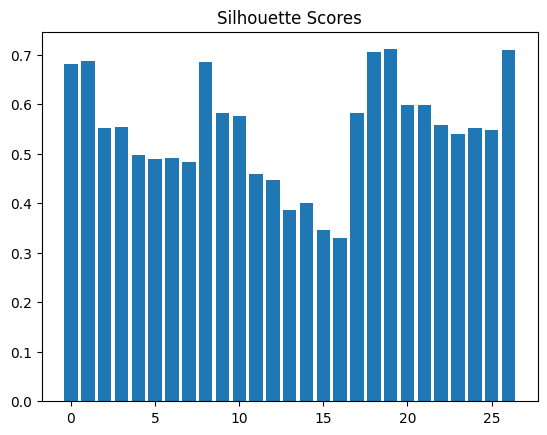

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, MeanShift

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

data = load_iris()
X = data.data

def evaluate(X, labels):
    return [
        silhouette_score(X, labels),
        calinski_harabasz_score(X, labels),
        davies_bouldin_score(X, labels)
    ]

results = []

def run_all(name, X_input):
    for k in [2, 3, 4, 5]:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_input)
        results.append([name, "KMeans", k] + evaluate(X_input, labels))

        hier = AgglomerativeClustering(n_clusters=k)
        labels = hier.fit_predict(X_input)
        results.append([name, "Hierarchical", k] + evaluate(X_input, labels))

    meanshift = MeanShift()
    labels = meanshift.fit_predict(X_input)
    if len(set(labels)) > 1:
        results.append([name, "MeanShift", len(set(labels))] + evaluate(X_input, labels))

run_all("No Processing", X)

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)
run_all("Normalization", X_norm)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
run_all("PCA", X_pca)

df = pd.DataFrame(results, columns=[
    "Preprocessing", "Algorithm", "Clusters",
    "Silhouette", "Calinski-Harabasz", "Davies-Bouldin"
])

print(df)

df.to_csv("results.csv", index=False)

plt.figure()
plt.bar(range(len(df)), df["Silhouette"])
plt.title("Silhouette Scores")
plt.show()